# Day 13: RNN & LSTM — 字符级文本生成

用 numpy 从零实现 RNN 和 LSTM，在 Tiny Shakespeare 数据集上训练字符级语言模型。

主要概念：
- RNN 的循环结构与 BPTT
- LSTM 的门控机制
- 自回归文本生成
- 温度采样


In [1]:
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.rnn import RNN, LSTM

np.random.seed(42)

In [2]:
# Load Tiny Shakespeare
import urllib.request
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
path = '../data/tinyshakespeare.txt'
if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
with open(path, 'r', encoding='utf-8') as f:
    text = f.read()

n_chars = 15000
text = text[:n_chars]
chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for i,c in enumerate(chars)}
data = np.array([char_to_idx[c] for c in text], dtype=int)
X, y = data[:-1], data[1:]

print(f'Vocab size: {len(chars)}')
print(f'Data length: {len(X)}')
chars_str = ''.join(chars)
print(f'Chars: {chars_str}')

Vocab size: 58
Data length: 14999
Chars: 
 !',-.:;?ABCDEFGHIJLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz


### 训练 RNN

In [3]:
rnn = RNN(hidden_size=100, lr=0.01, seq_length=25)
rnn.fit(X, y, epochs=50, verbose=True)
rnn.summary()

Epoch 0/50, loss: 3.2071


Epoch 5/50, loss: 2.2395


Epoch 10/50, loss: 2.1044


Epoch 15/50, loss: 2.1075


Epoch 20/50, loss: 2.0936


...

Epoch 30/50, loss: 3.0463


Epoch 35/50, loss: 3.0090


Epoch 40/50, loss: 2.9888


Epoch 45/50, loss: 3.0306


Weight                    Shape                Params    
-------------------------------------------------------
W_xh (input→hidden)       (100, 58)            5800      
W_hh (hidden→hidden)      (100, 100)           10000     
b_h                       (100, 1)             100       
W_hy (hidden→output)      (58, 100)            5800      
b_y                       (58, 1)              58        
-------------------------------------------------------
Total params                                   21758


### 训练 LSTM

In [4]:
lstm = LSTM(hidden_size=100, lr=0.01, seq_length=25)
lstm.fit(X, y, epochs=50, verbose=True)
lstm.summary()

Epoch 0/50, loss: 3.3457


Epoch 5/50, loss: 2.5248


Epoch 10/50, loss: 2.1448


Epoch 15/50, loss: 1.9488


Epoch 20/50, loss: 1.7882


...

Epoch 30/50, loss: 1.4970


Epoch 35/50, loss: 1.3959


Epoch 40/50, loss: 1.2883


Epoch 45/50, loss: 1.2002


Weight                    Shape                Params    
-------------------------------------------------------
W_f (forget gate)         (100, 158)           15800     
W_i (input gate)          (100, 158)           15800     
W_c (candidate)           (100, 158)           15800     
W_o (output gate)         (100, 158)           15800     
b_f/b_i/b_c/b_o           (100, 1) x4          400       
W_hy (hidden→output)      (58, 100)            5800      
b_y                       (58, 1)              58        
-------------------------------------------------------
Total params                                   69458


### 损失曲线对比

C:\Users\zaoquan\AppData\Local\Temp\ipykernel_1640\3832244737.py:15: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zaoquan\AppData\Local\Temp\ipykernel_1640\3832244737.py:15: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zaoquan\AppData\Local\Temp\ipykernel_1640\3832244737.py:15: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zaoquan\AppData\Local\Temp\ipykernel_1640\3832244737.py:15: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zaoquan\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zaoquan\AppData\Roaming\Python\Py

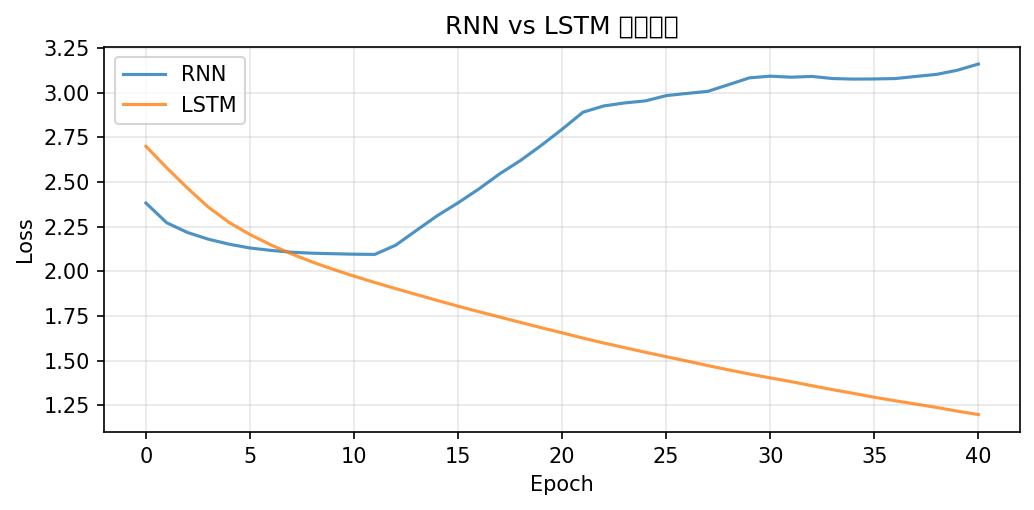

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

smooth = 10
fig, ax = plt.subplots(figsize=(7, 3.5))
rnn_s = np.convolve(rnn.losses_, np.ones(smooth)/smooth, mode='valid')
lstm_s = np.convolve(lstm.losses_, np.ones(smooth)/smooth, mode='valid')
ax.plot(rnn_s, label='RNN', alpha=0.8)
ax.plot(lstm_s, label='LSTM', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('RNN vs LSTM 收敛曲线')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 文本生成对比

In [6]:
def sample_text(model, seed_idx, n_chars=500, temp=0.8):
    indices = model.sample(seed_idx, n_chars=n_chars, temp=temp)
    return ''.join(idx_to_char[i] for i in indices)

seed = int(data[0])
print('=== RNN ===')
print(sample_text(rnn, seed, n_chars=500, temp=0.8))
print()
print('=== LSTM ===')
print(sample_text(lstm, seed, n_chars=500, temp=0.8))

=== RNN ===
Fer wafawis
yonaceonasU
Fhofbhasacuwonavean yhomenNyowouw

Aendoneifn
yom
lous
Aawinainitinawirop icaciniwenof
Aawouwiksesp

anow
Mhafdoneonyomeef
Tieawafey
Tonlaris
onabit iniiney

Aow
aoreacwonallowis

oo

hafosiinamorosaceegy
louninaweanayuwe
thowl,,om
Torf
Toinyosfansoworeriwoumachaninn

onasomg

aoriy honea,owhafamisinyfasefaw



oon
Aoinfon

inoua,

iwinnbewayoic afices
inawiwiwefiwyinsawoous
onomon
ofewsheindirsod.
Iiweb
hifawawid
yinrwyan whiwao
OafauriwhawfrRy
miyasymiwhiny

oumineneicyw

=== LSTM ===


Fore-hasted in a may thus?

First Senator:
Fire; Ioll he carria'
ITfer''ll wo suceved fan his nouner, ale
First Citizen:
I seell.

SeNoNISS:
A he than ang neare: you do be whos hawes: wis dead the gods age
to kees'll: whewe he'd accoust.

First Senator:
Farewell.

All:
Selake,
Our go bready of Rone.
Nails poury Iurs, I way stane he eart of your byou, do bear,!

First Senator:
AR, Carcius ghean bo do be word we him worthy heart, to be whos won hore. I sheed.
IThe peorder abo in what what we'ld con


### 不同温度采样效果

In [7]:
for temp in [0.3, 0.8, 1.2]:
    gen = sample_text(lstm, seed, n_chars=200, temp=temp)
    print(f'--- temp={temp} ---')
    print(gen)
    print()

--- temp=0.3 ---
First Citizen:
Where's heve what no answared you have when
I swere the great to mand the what alde show the pearres and hear, I shall knes's to you, where he wonle show Theyered on your off in re wors 



--- temp=0.8 ---
For his gower
is ack your offyer aboos your the atmend of the
speak kne wh's dy is rave for his cains
of my spook, I smade to ghere sayes of his veety your suffer one
To bunown where't to dooe bome hav

--- temp=1.2 ---
Finctensert! a msbell,

Ast netCere'd mepper: To where 't weil.

wEUIUS:
Vell, sor o' him of eareed you he proup:.

All:
Ape: Marmugh bo himcs of mus? whoud. IUld yet them core,
On heary kein your facy



### 预测示例：给定前缀，预测下一个字符

In [8]:
prefixes = ['The ', 'ROMEO: ', 'I ']

for prefix in prefixes:
    seed = [char_to_idx[c] for c in prefix]
    preds = lstm.predict(np.array(seed))
    next_chars = [idx_to_char[i] for i in preds]
    pred_str = ''.join(next_chars)
    print(f'{repr(prefix)} → 逐字符预测:')
    for i, (c, n) in enumerate(zip(prefix, pred_str)):
        print(f'  {repr(c)} → {repr(n)}')
    print()

'The ' → 逐字符预测:
  'T' → 'h'
  'h' → 'e'
  'e' → ' '
  ' ' → 'w'

'ROMEO: ' → 逐字符预测:
  'R' → 'o'
  'O' → ' '
  'M' → '\n'
  'E' → 'N'
  'O' → 'e'
  ':' → ' '
  ' ' → 'h'

'I ' → 逐字符预测:
  'I' → ' '
  ' ' → 'I'

